# Dow Data Challenge: PLS Regression
### CHE 891 — Week 2

We build a **Partial Least Squares (PLS)** regression model to predict impurity from the
40 process sensor variables. PLS is well-suited here because:

- The predictors are highly correlated (collinear sensors)
- We have far more variables than we need ($p = 40$, $n \approx 1000$)
- We want interpretable latent-variable structure

We start from the cleaned, filtered dataset exported from the Week 1 notebook.


In [50]:
import pandas as pd
import numpy as np
from pylab import *
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [51]:
training_url = 'http://egr.msu.edu/~scb/courses/EGR891/dow_training_clean.csv'
validation_url = 'http://egr.msu.edu/~scb/courses/EGR891/dow_validation_clean.csv'

df_train = pd.read_csv(training_url, parse_dates=['Date'])
df_val = pd.read_csv(validation_url, parse_dates=['Date'])
print(f"Training: {df_train.shape}")
df_train.head()

Training: (1927, 48)


,Date,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column,x6:Primary Column Make Flow,x7:Primary Column Base Level,x8:Primary Column Reflux Drum Pressure,x9:Primary Column Condenser Reflux Drum Level,...,x38: Feed Column Calculated DP,x39: Feed Column Steam Flow,x40: Feed Column Tails Flow,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y:Impurity,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio,x16x17L,x16x17H
0,2015-12-01 00:00:00,327.813,45.7920,2095.06,2156.01,98.5005,95.4674,54.3476,41.0121,52.2353,...,66.6604,8.68813,99.9614,5.38024,1.49709,1.77833,3.32803,0.291226,23.4202,52.6953
1,2015-12-01 09:00:00,327.686,45.8192,2109.75,2185.82,98.8448,95.5414,54.0806,41.0029,53.0875,...,65.5845,8.69685,100.2790,5.31385,1.51268,1.70012,3.31516,0.291564,22.6707,53.3360
2,2015-12-01 14:00:00,322.439,46.0614,2108.64,2124.04,96.8568,94.1683,54.5115,40.9982,53.3624,...,69.2825,8.70710,99.8578,5.29914,1.52085,1.41000,3.32903,0.292050,25.4557,53.9291
3,2015-12-01 15:00:00,322.402,45.9821,2104.28,2233.15,96.8940,94.1798,54.2862,40.9888,53.2537,...,67.9772,8.72056,99.9187,5.32702,1.51294,1.44087,3.32737,0.292119,25.7638,53.4808
4,2015-12-01 20:00:00,330.082,45.9936,2104.54,2171.53,98.4124,96.2888,55.2908,40.9888,53.3826,...,66.7390,8.69239,99.8563,5.44890,1.51592,1.68766,3.35407,0.291712,22.3133,52.8688


## 2. Prepare X and y

In [52]:
feat_cols = [c for c in df_train.columns
             if c.startswith('x') ]

X_train = df_train[feat_cols].values
y_train = df_train['y:Impurity'].values
X_val = df_val[feat_cols].values
y_val = df_val['y:Impurity'].values

print(f"Features: {len(feat_cols)}")
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")



Features: 42
X_train: (1927, 42)  y_train: (1927,)
X_val: (5891, 42)  y_val: (5891,)


## 3. Create Pipeline


In [53]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('pls',    PLSRegression(n_components=1))])

## 4. Choose the Number of PLS Components

Use cross-validation RMSE to choose $A$ — the number of latent variables.
More components = better training fit, but risk of overfitting.


In [54]:
# use double underscore to set pls attibutes via pipeline                                                           
gs = GridSearchCV(pipe,                                      
                {'pls__n_components': range(1, 15)},
                cv=5,
                
                scoring='r2',
                refit=True,
                return_train_score=True)

gs.fit(X_train, y_train)

r2 = gs.cv_results_['mean_train_score']
q2 = gs.cv_results_['mean_test_score']
A  = list(gs.cv_results_['param_pls__n_components'])

best_A = gs.best_params_['pls__n_components']
print(f"Best A: {best_A}")
print(f"Best Q²: {gs.best_score_:.3f}")






Best A: 5
Best Q²: 0.416


### Plot

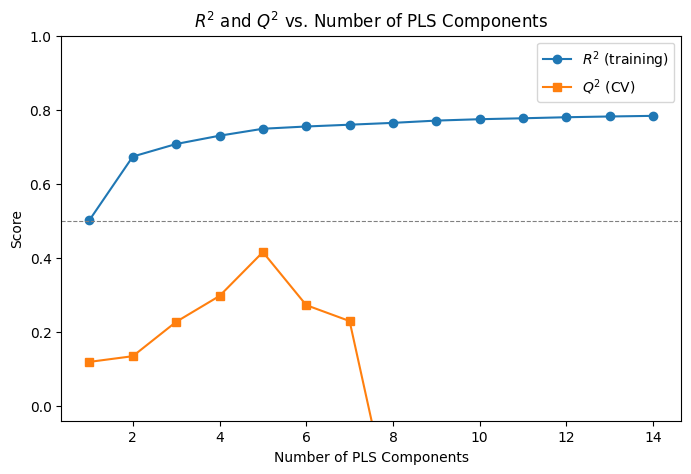

In [55]:
figure(figsize=(8, 5))
plot(A, r2, 'o-', label='$R^2$ (training)')
plot(A, q2, 's-', label='$Q^2$ (CV)')
ylim(-.04, 1)
xlabel('Number of PLS Components')
ylabel('Score')
title('$R^2$ and $Q^2$ vs. Number of PLS Components')
legend()
axhline(0.5, color='gray', ls='--', lw=0.8, label='$Q^2$ = 0.5 threshold')
show()

A rough rule of thumb from chemometrics (Eriksson, Wold et
  al.):
  - Q² > 0.5 is considered acceptable
  - Q² > 0.9 is excellent
  - R² − Q² > 0.2–0.3 is a warning sign of overfitting

## 5. Fit Final PLS Model


In [56]:
A = best_A   # use CV-selected number of PLS components

pipe.set_params(pls__n_components=A)
pipe.fit(X_train, y_train)

y_train_pred = pipe.predict(X_train)

r2_tr   = r2_score(y_train, y_train_pred)
rmse_tr = mean_squared_error(y_train, y_train_pred)**0.5

print(f"A = {A}")
print(f"Training:  R² = {r2_tr:.3f}   RMSE = {rmse_tr:.4f}")


A = 5
Training:  R² = 0.747   RMSE = 0.5691


## 6. Predicted vs. Actual


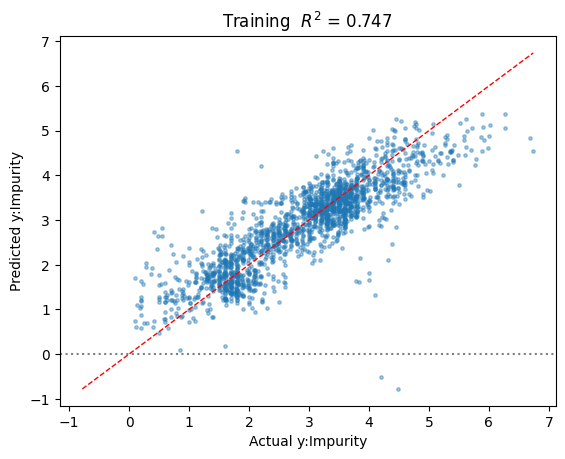

In [57]:
scatter(y_train, y_train_pred, s=6, alpha=0.4)
lims = [min(y_train.min(), y_train_pred.min()),
        max(y_train.max(), y_train_pred.max())]
plot(lims, lims, 'r--', lw=1)
xlabel('Actual y:Impurity')
ylabel('Predicted y:Impurity')
title(f'Training  $R^2$ = {r2_tr:.3f}')
axhline(0, ls=':', color='gray')
show()


## 7. VIP Scores — Which Sensors Matter?

For ranking variable importance, PLS has a dedicated metric: **VIP** (Variable Importance in Projection). It accounts for all components simultaneously:

$$\text{VIP}_k = \sqrt{K \cdot \frac{\sum_{a=1}^{A} (w_{ka}^*)^2 \cdot \text{SS}_a}{\sum_{a=1}^{A} \text{SS}_a}}$$

where $\text{SS}_a = c_a^2 \, t_a' t_a$ is the amount of y-variance explained by component $a$, and $w_{ka}^*$ is the transformed weight for variable $k$ in component $a$.

**Intuition:** VIP asks "how much does variable $k$ contribute to the scores, weighted by how much each score matters for predicting y?"

**Rules of thumb:**

| VIP value | Interpretation |
|-----------|---------------|
| > 1 | Important variable |
| 0.5 – 1 | Moderate, possibly useful |
| < 0.5 | Candidate for removal |


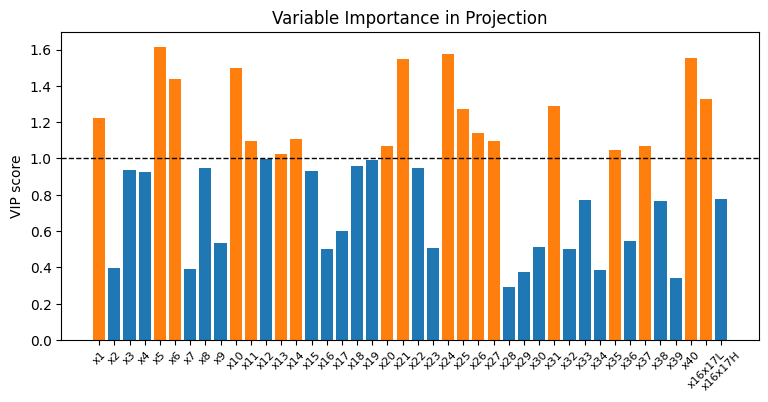

Index(['x1:Primary Column Reflux Flow',
       'x5:Primary Column Feed Flow from Feed Column',
       'x6:Primary Column Make Flow', 'x10:Primary Column Bed1 DP',
       'x11:Primary Column Bed2 DP', 'x13:Primary Column Bed4 DP',
       'x14:Primary Column Base Pressure',
       'x20:Primary Column Bed 2 Temperature',
       'x21:Primary Column Bed 1 Temperature',
       'x24: Secondary Column Tails Flow', 'x25: Secondary Column Tray DP',
       'x26: Secondary Column Head Pressure',
       'x27: Secondary Column Base Pressure',
       'x31: Secondary Column Bed 2 Temperature',
       'x35: Secondary Column Tails Concentration',
       'x37: Feed Column Tails Flow to Primary Column',
       'x40: Feed Column Tails Flow', 'x16x17L'],
      dtype='str')

In [58]:
def vip_scores(pls, X_scaled):
  T = pls.transform(X_scaled)      # scores  (n, A)        
  W = pls.x_rotations_             # W*      (p, A)
  Q = pls.y_loadings_.ravel()      # q       (A,)

  p, A = W.shape

  # Normalize W* columns
  W_norm = W / np.linalg.norm(W, axis=0)

  # SS explained in y by each component
  SS = np.diag(T.T @ T) * Q**2    # (A,)

  return np.sqrt(p * (W_norm**2 @ SS) / SS.sum())
X_s  = pipe['scaler'].transform(X_train)
vip  = vip_scores(pipe['pls'], X_s)
# Plot
short_names = [c.split(':')[0] for c in feat_cols]
colors = ['C1' if v >= 1 else 'C0' for v in vip]

figure(figsize=[9,4])
bar(range(len(vip)), vip, color=colors)
axhline(1, color='k', lw=1, ls='--')
gca().set_xticks(range(len(vip)))
gca().set_xticklabels(short_names, rotation=45, fontsize=8)
ylabel('VIP score')
title('Variable Importance in Projection')
show()
df_train[feat_cols].columns[vip>=1]

## 8. Prediction Over Time

Plot predicted and actual impurity on the validation set to see where the model
succeeds and fails.


### Training Set

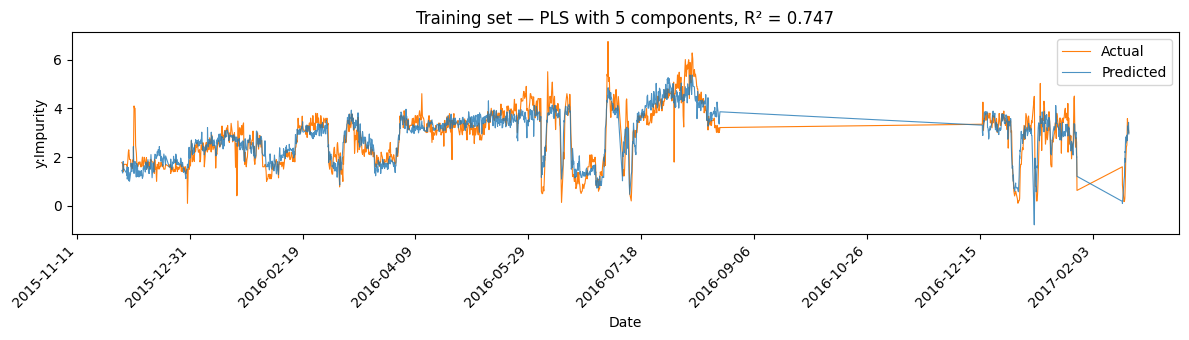

In [59]:
fig, ax = subplots(figsize=(12, 3.5))



ax.plot(df_train['Date'], y_train,      lw=0.8, label='Actual',    color='C1')
ax.plot(df_train['Date'], y_train_pred, lw=0.8, label='Predicted', color='C0', alpha=0.8)
ax.set_ylabel('y:Impurity')
ax.set_xlabel('Date')
ax.set_title(f'Training set — PLS with {A} components, R² = {r2_tr:.3f}')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
tight_layout()

show()


### Validation Set

In [60]:
import plotly.graph_objects as go

# Clean validation set - replace '!' with NaN and convert to numeric
df_val_clean = df_val.copy()
for col in df_val_clean.columns:
    if col != 'Date':
        df_val_clean[col] = pd.to_numeric(df_val_clean[col].replace('!', np.nan), errors='coerce')

drop_threshhold = 0.5
min_valid = int(drop_threshhold * len(df_val_clean.columns))
df_val_clean = df_val_clean.dropna(thresh=min_valid, axis=0)
df_val_clean = df_val_clean.interpolate()
df_val_clean = df_val_clean.reset_index(drop=True)

# Remove rows where y:Impurity > 10
df_val_clean = df_val_clean[df_val_clean['y:Impurity'] <= 10]
df_val_clean = df_val_clean.reset_index(drop=True)

# Re-extract X and y from cleaned data
X_val_clean = df_val_clean[feat_cols].values
y_val_clean = df_val_clean['y:Impurity'].values

print(f"Cleaned validation set shape: {df_val_clean.shape}")

# Predict on validation set using model trained on training data
y_val_pred = pipe.predict(X_val_clean)

r2_val = r2_score(y_val_clean, y_val_pred)
rmse_val = mean_squared_error(y_val_clean, y_val_pred)**0.5

print(f"Validation:  R² = {r2_val:.3f}   RMSE = {rmse_val:.4f}")

# Interactive plot with plotly (supports zoom, pan, hover)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_val_clean['Date'], y=y_val_clean, 
                         mode='markers', name='Actual', marker=dict(color='orange', size=4)))
fig.add_trace(go.Scatter(x=df_val_clean['Date'], y=y_val_pred.ravel(), 
                         mode='markers', name='Predicted', marker=dict(color='blue', size=4), opacity=0.8))
fig.update_layout(
    title=f'Validation set — PLS with {A} components, R² = {r2_val:.3f}',
    xaxis_title='Date',
    yaxis_title='y:Impurity',
    hovermode='x unified',
    height=400
)
fig.show()

Cleaned validation set shape: (5891, 48)
Validation:  R² = -0.911   RMSE = 1.3094


## 9. Discussion

> **Q1:** How many components did cross-validation select? Does that seem physically
> reasonable given the number of known process subsystems?

> **Q2:** Which sensors have the largest VIP score? Do they correspond to
> variables you'd expect to drive impurity based on process knowledge?

> **Q3:** Where does the model fail on the validation set? Can you identify those
> periods using PCA analysis?

> **Q4:** Have we scaled the $y$ data?  What effect does this have?

*(Your answers here)*

Q1: There were 5 conponents selected for PLS, which implies there is a lot of overlap or complementary sensors.
Q2: The sensors with the largest VIP score appear to primarily be mass flow rates for some of the most important systems, with a few temperature sensors of secondary importance. Despite having multiple sensons on each piece of equipment, the highest VIP scores appear only once per piece.
Q3: The model seems to fail by falsely predicting a few spikes in impurity concentration. 
Q4: We have not scaled the $y$ data, so the determination of PLS might be dominated by outliers. I think a logistic scaling will improve this.


## 10. Softplus transformation
To maintain positive values of impurity we transform the $y$ data using the softplus function (Qin Eq. 1):

$$ 
y=\ln \left(e^z+1\right)=s_{+}(z),
$$

to use softplus with the pipeline, we wrap everything in a `TransformedTargetRegressor`

In [61]:
def softplus(z):
    return np.logaddexp(z, 0)       # log(1 + exp(z)), numerically stable  z -> y

def softplus_inv(y):
    y = np.clip(y, 1e-12, None)     # guard against non-positive values
    return np.log(np.expm1(y))      # log(exp(y) - 1), valid for y > 0     y -> z

model = TransformedTargetRegressor(
    regressor=pipe,
    func=softplus_inv,      # applied to y before fitting:  y -> z
    inverse_func=softplus   # applied to predictions:       z -> y
)

model.fit(X_train, y_train)


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...mponents=5))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<function sof...0025BED5EECA0>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<function sof...0025BE139A980>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",5
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500


In [62]:
# you: redo Sections 7 and 8 with the softplus scaling and compare to Qin et al.

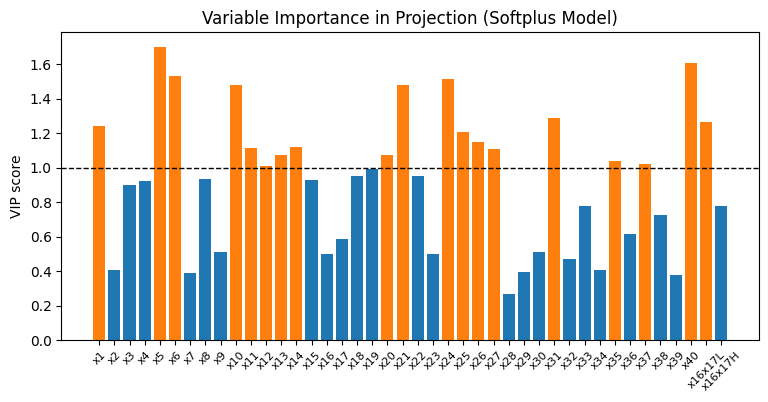

Index(['x1:Primary Column Reflux Flow',
       'x5:Primary Column Feed Flow from Feed Column',
       'x6:Primary Column Make Flow', 'x10:Primary Column Bed1 DP',
       'x11:Primary Column Bed2 DP', 'x12:Primary Column Bed3 DP',
       'x13:Primary Column Bed4 DP', 'x14:Primary Column Base Pressure',
       'x20:Primary Column Bed 2 Temperature',
       'x21:Primary Column Bed 1 Temperature',
       'x24: Secondary Column Tails Flow', 'x25: Secondary Column Tray DP',
       'x26: Secondary Column Head Pressure',
       'x27: Secondary Column Base Pressure',
       'x31: Secondary Column Bed 2 Temperature',
       'x35: Secondary Column Tails Concentration',
       'x37: Feed Column Tails Flow to Primary Column',
       'x40: Feed Column Tails Flow', 'x16x17L'],
      dtype='str')

In [63]:
# Access inner fitted pipeline from softplus model
inner_pipe = model.regressor_

def vip_scores(pls, X_scaled):
  T = pls.transform(X_scaled)      # scores  (n, A)        
  W = pls.x_rotations_             # W*      (p, A)
  Q = pls.y_loadings_.ravel()      # q       (A,)

  p, A = W.shape

  # Normalize W* columns
  W_norm = W / np.linalg.norm(W, axis=0)

  # SS explained in y by each component
  SS = np.diag(T.T @ T) * Q**2    # (A,)

  return np.sqrt(p * (W_norm**2 @ SS) / SS.sum())

# Use inner pipeline's scaler and PLS
X_s_softplus = inner_pipe['scaler'].transform(X_train)
vip_softplus = vip_scores(inner_pipe['pls'], X_s_softplus)

# Plot
short_names = [c.split(':')[0] for c in feat_cols]
colors = ['C1' if v >= 1 else 'C0' for v in vip_softplus]

figure(figsize=[9,4])
bar(range(len(vip_softplus)), vip_softplus, color=colors)
axhline(1, color='k', lw=1, ls='--')
gca().set_xticks(range(len(vip_softplus)))
gca().set_xticklabels(short_names, rotation=45, fontsize=8)
ylabel('VIP score')
title('Variable Importance in Projection (Softplus Model)')
show()
df_train[feat_cols].columns[vip_softplus>=1]

Softplus Model Training:  R² = 0.762   RMSE = 0.5523


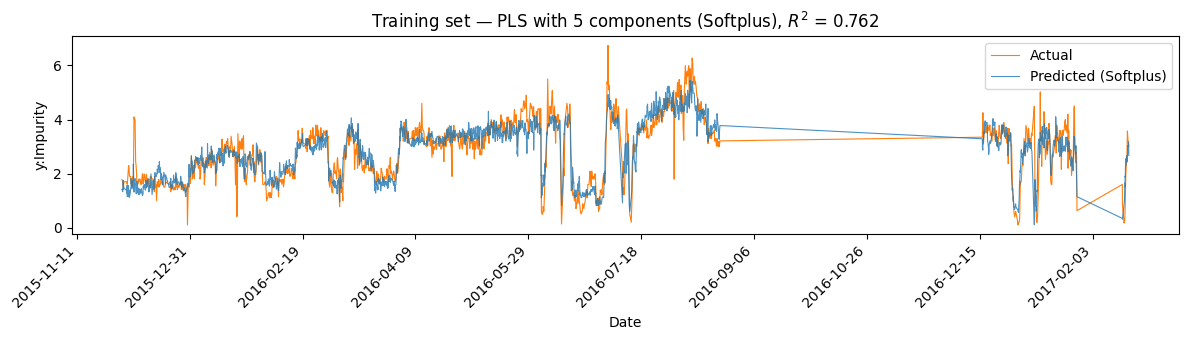

In [64]:
# Predictions using softplus model
y_train_pred_softplus = model.predict(X_train)

r2_tr_softplus = r2_score(y_train, y_train_pred_softplus)
rmse_tr_softplus = mean_squared_error(y_train, y_train_pred_softplus)**0.5

print(f"Softplus Model Training:  R² = {r2_tr_softplus:.3f}   RMSE = {rmse_tr_softplus:.4f}")

fig, ax = subplots(figsize=(12, 3.5))
ax.plot(df_train['Date'], y_train, lw=0.8, label='Actual', color='C1')
ax.plot(df_train['Date'], y_train_pred_softplus, lw=0.8, label='Predicted (Softplus)', color='C0', alpha=0.8)
ax.set_ylabel('y:Impurity')
ax.set_xlabel('Date')
ax.set_title(f'Training set — PLS with {A} components (Softplus), $R^2$ = {r2_tr_softplus:.3f}')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
tight_layout()
show()

In [65]:
import plotly.graph_objects as go

# Clean validation set - replace '!' with NaN and convert to numeric
df_val_clean = df_val.copy()
for col in df_val_clean.columns:
    if col != 'Date':
        df_val_clean[col] = pd.to_numeric(df_val_clean[col].replace('!', np.nan), errors='coerce')

drop_threshhold = 0.5
min_valid = int(drop_threshhold * len(df_val_clean.columns))
df_val_clean = df_val_clean.dropna(thresh=min_valid, axis=0)
df_val_clean = df_val_clean.interpolate()

# Match prior validation rule to reduce influence of extreme outliers
df_val_clean = df_val_clean[df_val_clean['y:Impurity'] <= 10]
df_val_clean = df_val_clean.reset_index(drop=True)

# Re-extract X and y from cleaned data
X_val_clean = df_val_clean[feat_cols].values
y_val_clean = df_val_clean['y:Impurity'].values

print(f"Cleaned validation set shape: {df_val_clean.shape}")

# Baseline (no target transform)
y_val_pred_plain = pipe.predict(X_val_clean)
r2_val_plain = r2_score(y_val_clean, y_val_pred_plain)

# Softplus target-transform model
y_val_pred_softplus = model.predict(X_val_clean)
r2_val_softplus = r2_score(y_val_clean, y_val_pred_softplus)
rmse_val_softplus = mean_squared_error(y_val_clean, y_val_pred_softplus)**0.5

print(f"Validation (Plain PLS):      R² = {r2_val_plain:.3f}")
print(f"Validation (Softplus PLS):   R² = {r2_val_softplus:.3f}   RMSE = {rmse_val_softplus:.4f}")

# Interactive plot with plotly (supports zoom, pan, hover)
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_val_clean['Date'], y=y_val_clean,
                         mode='markers', name='Actual', marker=dict(color='orange', size=4)))
fig.add_trace(go.Scatter(x=df_val_clean['Date'], y=y_val_pred_softplus.ravel(),
                         mode='markers', name='Predicted (Softplus)', marker=dict(color='blue', size=4), opacity=0.8))
fig.update_layout(
    title=f'Validation set - PLS with {A} components (Softplus), R² = {r2_val_softplus:.3f}',
    xaxis_title='Date',
    yaxis_title='y:Impurity',
    hovermode='x unified',
    height=400
)
fig.show()


Cleaned validation set shape: (5891, 48)
Validation (Plain PLS):      R² = -0.911
Validation (Softplus PLS):   R² = -1.062   RMSE = 1.3603


HW answer for question 1:

The R^2 value for the training set it mediocre and below the findings of Qin et al, but is much worse on the validation set. The negative R^2 value on validation indicates that my model is performing worse than a system mean prediction, with a significant contribution from the several huge spikes that are erroneously predicted. This poor performance will likely be improved by the addition of OBL, but I suspect that several of the preprocessing steps that I added, different than Qin et al., did more harm than good. I specifically tried to remove large spikes in the actual data under the assumption that these were noise and did not represent actual process conditions, but this was likely not true. 